In [71]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder , StandardScaler
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error , root_mean_squared_error , r2_score


In [4]:
df = pd .read_csv ("Housing.csv")

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 69.2 KB


In [6]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

In [7]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [8]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [9]:
df.isna().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
numColumn = df.select_dtypes(include='number')

<Axes: >

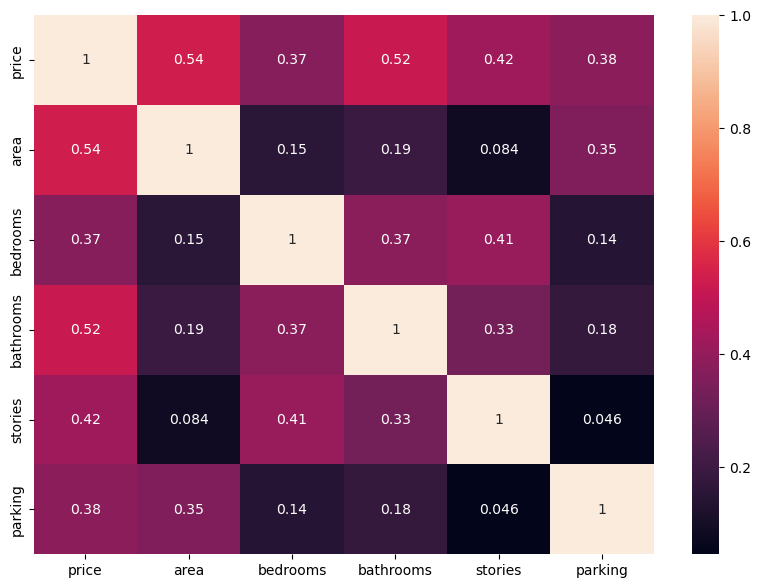

In [12]:
plt.figure(figsize=(10,7))
sns.heatmap(numColumn.corr(),  annot=True)

In [13]:
numColumn

,price,area,bedrooms,bathrooms,stories,parking
0,13300000,7420,4,2,3,2
1,12250000,8960,4,4,4,3
2,12250000,9960,3,2,2,2
3,12215000,7500,4,2,2,3
4,11410000,7420,4,1,2,2
...,...,...,...,...,...,...
540,1820000,3000,2,1,1,2
541,1767150,2400,3,1,1,0
542,1750000,3620,2,1,1,0
543,1750000,2910,3,1,1,0


In [14]:
numeric_cols = ["price", "area", "bedrooms", "bathrooms", "stories", "parking"]


In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,545.0,4.766729e+06,1.870440e+06,1750000.0,3430000.0,4340000.0,5740000.0,13300000.0
area,545.0,5.150541e+03,2.170141e+03,1650.0,3600.0,4600.0,6360.0,16200.0
bedrooms,545.0,2.965138e+00,7.380639e-01,1.0,2.0,3.0,3.0,6.0
bathrooms,545.0,1.286239e+00,5.024696e-01,1.0,1.0,1.0,2.0,4.0
stories,545.0,1.805505e+00,8.674925e-01,1.0,1.0,2.0,2.0,4.0
parking,545.0,6.935780e-01,8.615858e-01,0.0,0.0,0.0,1.0,3.0



--- mainroad ---


mainroad
yes    468
no      77
Name: count, dtype: int64


--- guestroom ---


guestroom
no     448
yes     97
Name: count, dtype: int64


--- basement ---


...

airconditioning
no     373
yes    172
Name: count, dtype: int64


--- prefarea ---


prefarea
no     417
yes    128
Name: count, dtype: int64


--- furnishingstatus ---


furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64

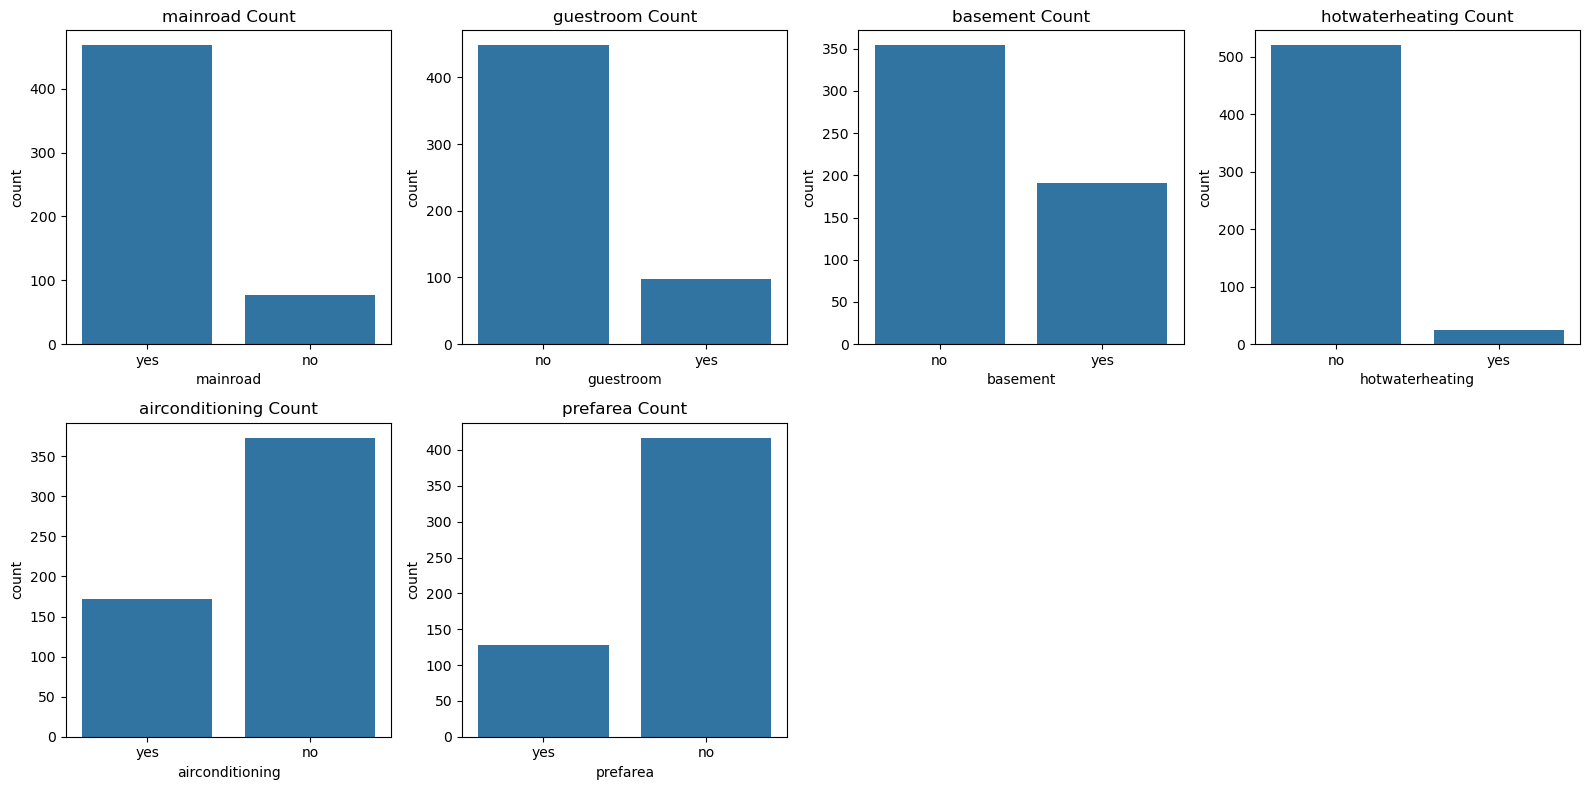

In [42]:
# for col in numeric_cols :
#     plt.Figure(figsize=(10,3))
    
#     plt.subplot(1,2,1)
#     sns.histplot(df[col] ,  kde=True)
#     plt.title(f"{col} Distribution")
    
#     plt.subplot(1,2,2)
#     sns.boxplot(x = df[col])
#     plt.title(f"{col} Boxplot")
    
#     plt.tight_layout()
#     plt.show
    
plt.figure(figsize=(16, 8))

for i, col in enumerate(categorical_cols):
    print(f"\n--- {col} ---")
    display(df[col].value_counts())
    
    plt.subplot(2, 4, i + 1)
    
    sns.countplot(data=df, x=col)
    plt.title(f"{col} Count")

# حذف الـ subplot الثامن الفاضي
plt.delaxes(plt.gcf().axes[-1])

plt.tight_layout()
plt.show()

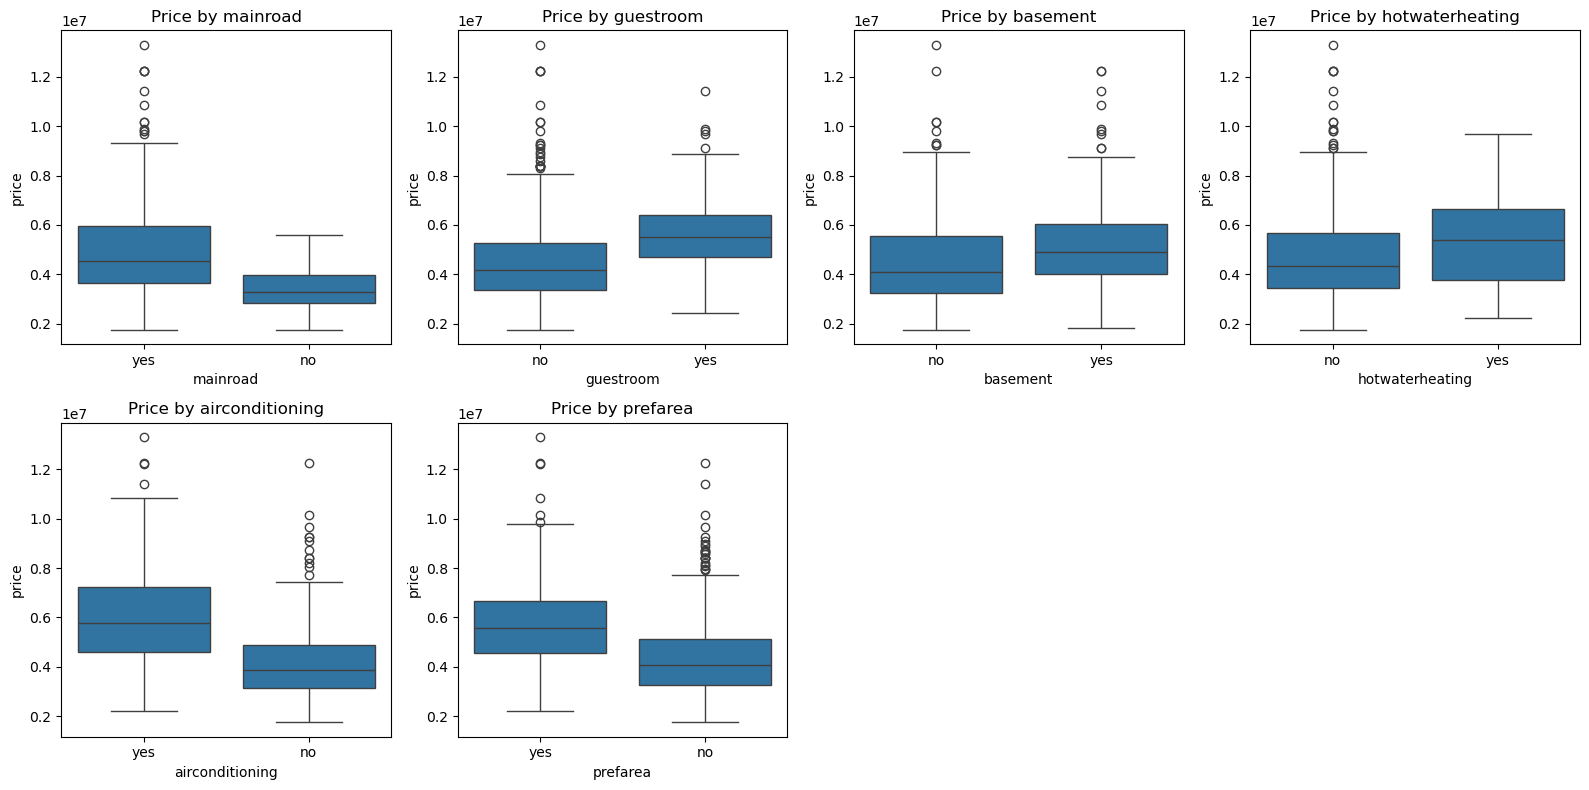

In [45]:
categorical_cols = [
    "mainroad", "guestroom", "basement",
    "hotwaterheating", "airconditioning",
    "prefarea", "furnishingstatus"
]

plt.figure(figsize=(16, 8))

for i, col in enumerate(categorical_cols):
    plt.subplot(2, 4, i + 1)

    sns.boxplot(data=df, x=col, y="price")
    plt.title(f"Price by {col}")

plt.delaxes(plt.gcf().axes[-1])

plt.tight_layout()
plt.show()

In [35]:
X = df.drop("price", axis=1) 
y = df["price"]               

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (436, 12)
X_test shape : (109, 12)
y_train shape: (436,)
y_test shape : (109,)


In [36]:
train_df = X_train.copy()
train_df["price"] = y_train

print(train_df.shape)
train_df[["price", "area"]].describe()

(436, 13)


,price,area
count,4.360000e+02,436.000000
mean,4.706527e+06,5154.144495
std,1.757976e+06,2204.313664
min,1.750000e+06,1650.000000
25%,3.498250e+06,3600.000000
50%,4.291000e+06,4500.000000
75%,5.600000e+06,6360.000000
max,1.225000e+07,16200.000000


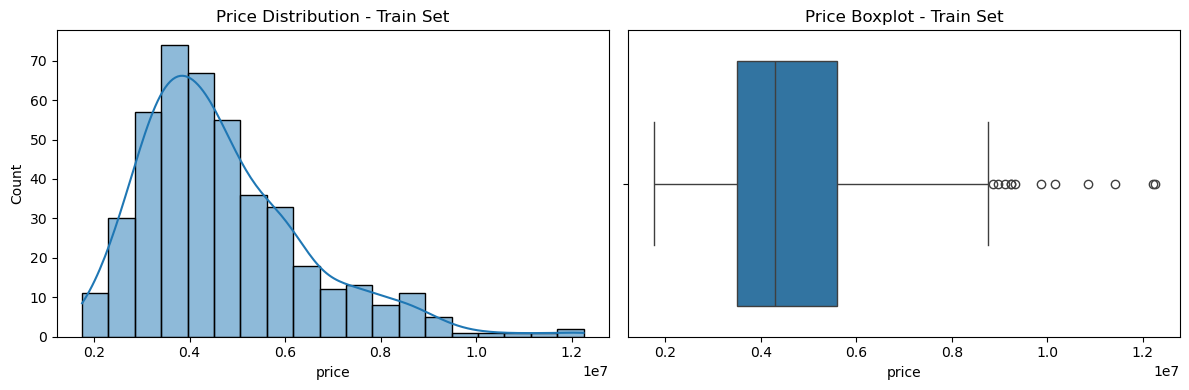

In [37]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(train_df["price"], kde=True)
plt.title("Price Distribution - Train Set")

plt.subplot(1, 2, 2)
sns.boxplot(x=train_df["price"])
plt.title("Price Boxplot - Train Set")

plt.tight_layout()
plt.show()

In [46]:
from sklearn.preprocessing import PowerTransformer

In [48]:
area_skew = X_train['area']

pt= PowerTransformer(method='yeo-johnson')
X_train['area'] = pt .fit_transform (X_train[ ["area"]])
X_test['area'] = pt.transform(X_test[['area']])


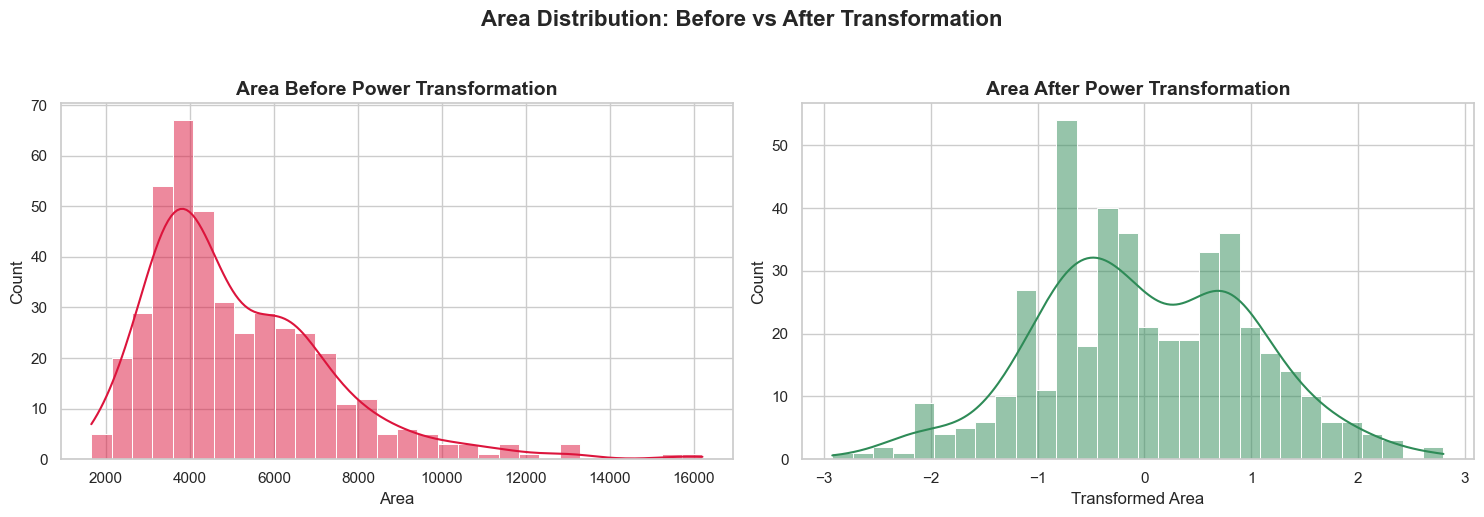

In [52]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Original area: غالبًا Skewed
sns.histplot(
    area_skew,
    kde=True,
    bins=30,
    color="crimson",
    edgecolor="white",
    linewidth=0.7,
    ax=axes[0]
)

axes[0].set_title("Area Before Power Transformation", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Area")
axes[0].set_ylabel("Count")

# Area after Power Transformation
sns.histplot(
    X_train.area,
    kde=True,
    bins=30,
    color="seagreen",
    edgecolor="white",
    linewidth=0.7,
    ax=axes[1]
)

axes[1].set_title("Area After Power Transformation", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Transformed Area")
axes[1].set_ylabel("Count")

fig.suptitle("Area Distribution: Before vs After Transformation",
             fontsize=16, fontweight="bold", y=1.03)

plt.tight_layout()
plt.show()

In [ ]:
scaler = StandardScaler()

X_train[numeric_cols[1:]] = scaler.fit_transform(X_train[numeric_cols[1:]])
X_test[numeric_cols[1:]] = scaler.transform(X_test[numeric_cols[1:]])

In [70]:
onehot = OneHotEncoder(sparse_output=False , handle_unknown= 'ignore')

train_oh = onehot.fit_transform(X_train[categorical_cols])
test_oh = onehot.transform(X_test[categorical_cols])

train_oh_frame = pd.DataFrame(train_oh , columns=onehot.get_feature_names_out() , index=X_train.index)
test_oh_frame = pd.DataFrame(test_oh , columns=onehot.get_feature_names_out() , index=X_test.index)

train_final = pd.concat([X_train[numeric_cols[1:]] , train_oh_frame] , axis = 1)
test_final = pd.concat([X_test[numeric_cols[1:]] , test_oh_frame] , axis = 1)

In [69]:
test_final

,area,bedrooms,bathrooms,stories,parking,mainroad_no,mainroad_yes,guestroom_no,guestroom_yes,basement_no,basement_yes,hotwaterheating_no,hotwaterheating_yes,airconditioning_no,airconditioning_yes,prefarea_no,prefarea_yes,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
316,0.572477,1.394055,1.539173,0.254215,0.367957,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
77,0.805027,0.055271,1.539173,1.420929,-0.803059,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
360,-0.379055,-1.283514,-0.557950,-0.912499,-0.803059,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
90,0.165015,0.055271,-0.557950,0.254215,-0.803059,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
493,-0.431237,0.055271,-0.557950,-0.912499,-0.803059,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15,0.613141,1.394055,-0.557950,0.254215,1.538972,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
357,0.956503,1.394055,-0.557950,0.254215,0.367957,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
39,0.613141,1.394055,1.539173,2.587644,0.367957,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
54,0.613141,0.055271,1.539173,0.254215,0.367957,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [80]:
lr = LinearRegression()

lr.fit(train_final , y_train)
ypred = lr.predict(test_final)

mse = mean_squared_error(y_test , ypred)
rmse = root_mean_squared_error(y_test , ypred)
r2 = r2_score(y_test , ypred)

print(f'Mean Squared Error : {mse}')
print(f'Root Mean Squared Error : {rmse}')
print(f'R2 Score : {r2}')

Mean Squared Error : 1779988068415.6814
Root Mean Squared Error : 1334161.9348548667
R2 Score : 0.6478458144492865
